# Project: Essay Writer

## Defining the AgentState and the Prompts

In [ ]:
# Install all required packages
%pip install -q -r requirements.txt

In [1]:
# Loading the API key from .env
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [3]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model='gpt-5.1', temperature=0)

In [4]:
from typing import TypedDict, List, Annotated

# Creating a class for the agent state
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [5]:
# Defining the planning prompt 
PLAN_PROMPT = '''You are an expert writer tasked with writing a high level outline of an essay.
Write such an outline for the user provided topic.
Give an outline of the essay along with any relevant notes or instructions for the sections.'''

# defining the prompt that will be used by the agent that's doing research after the planning step
# given a plan, it will generate some queries and pass them to Tavily
RESEARCH_PLAN_PROMPT = '''You are a researcher charged with providing information that can be used when writing the following essay.
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max.'''

# Defining the writer prompt
WRITER_PROMPT = '''You are an essay assistant tasked with writing excellent 5-paragraph essays.
Generate the best essay possible for the user's request and the initial outline.
If the user provides critique, respond with a revised version of your previous attempts.
Utilize all the information below as needed: 

------

{content}'''

# Defining the reflection prompt
REFLECTION_PROMPT = '''You are a teacher grading an essay submission.
Generate critique and recommendations for the user's submission.
Provide detailed recommendations, including requests for length, depth, style, etc.'''

# Defining the research critique prompt
RESEARCH_CRITIQUE_PROMPT = ''''You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below).
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max.'''


In [7]:
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [8]:
# Importing and instantiating a tavily client
from tavily import TavilyClient
import os

tavily = TavilyClient(api_key=os.environ['TAVILY_API_KEY'])


## Implementing the Agents and the Nodes

In [9]:
# Creating the planning node
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}


In [10]:
# Creating the reseach_plan_node
# It generates research queries based on a given task and retrieves relevant content using those queries
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    # content = state['content'] or [] # fix - change to this:
    content = state.get('content', [])
    
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}


In [11]:
# Creating the generation node
def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    
    response = model.invoke(messages)
     
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }


In [12]:
# Creating the reflection node
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}



In [13]:
# Creating the research critique node
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {'content': content}


## Defining the Conditional Edge

In [14]:
# Defining the conditional edge
def should_continue(state):
    if state['revision_number'] > state['max_revisions']:
        return END
    return 'reflect'


## Defining the Graph

In [15]:
builder = StateGraph(AgentState)

# Adding nodes to the graph
builder.add_node('planner', plan_node)
builder.add_node('generate', generation_node)
builder.add_node('reflect', reflection_node)
builder.add_node('research_plan', research_plan_node)
builder.add_node('research_critique', research_critique_node)

# Setting the entry point of the state graph
builder.set_entry_point('planner')

# Adding the conditional edge
builder.add_conditional_edges(
    'generate', 
    should_continue, 
    {END: END, 'reflect': 'reflect'}
)

# Adding regular edges
builder.add_edge('planner', 'research_plan')
builder.add_edge('research_plan', 'generate')

builder.add_edge('reflect', 'research_critique')
builder.add_edge('research_critique', 'generate')


In [ ]:
# pip install -q langgraph-checkpoint-sqlite

Note: you may need to restart the kernel to use updated packages.


In [16]:
from langgraph.checkpoint.sqlite import SqliteSaver
# fix - import this
from langgraph.checkpoint.memory import MemorySaver

memory = SqliteSaver.from_conn_string(':memory:')

# graph = builder.compile(checkpointer=memory) # fix - change to this:
graph = builder.compile(checkpointer=MemorySaver())

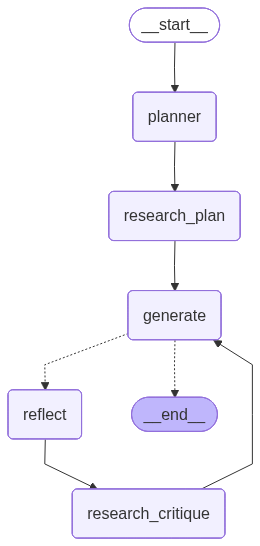

In [18]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## Running the Agentic App

In [19]:
thread = {'configurable': {'thread_id': '1'}}
task = 'Nvidia  Blackwell AI chip'

prompt = {
    'task': task,
    'max_revisions': 2,
    'revision_number': 1,
}

events = graph.stream(prompt, thread)
for e in events:
    print(e)
    print('-' * 100)

{'planner': {'plan': '**Working Title:**  \nNvidia’s Blackwell AI Chip: Architecture, Impact, and the Future of Accelerated Computing\n\n---\n\n## I. Introduction\n- **Purpose of the essay**  \n  - Introduce Nvidia’s Blackwell as the successor to Hopper, positioned as the next major leap in AI accelerators.\n  - Frame Blackwell’s significance in the context of the AI boom (LLMs, generative AI, data center demand).\n- **Thesis / central argument**  \n  - Blackwell is not just a faster chip; it represents a platform shift in how large-scale AI workloads are built, optimized, and deployed across cloud, enterprise, and edge.\n\n---\n\n## II. Background: From GPUs to AI Superchips\n- **Nvidia’s evolution in AI**  \n  - Brief history: from gaming GPUs → CUDA → data center GPUs → Hopper → Blackwell.\n  - Importance of software ecosystem (CUDA, cuDNN, TensorRT, etc.) in magnifying hardware advances.\n- **The Hopper generation (context for comparison)**  \n  - What H100 brought: transformer eng

In [20]:
print(e['generate']['draft'])

Nvidia’s Blackwell AI Chip: Architecture, Impact, and the Future of Accelerated Computing
---------------------------------------------------------------------------------------

Over the past decade, Nvidia has transformed from a gaming graphics company into the central supplier of infrastructure for modern artificial intelligence. Each architectural generation—Volta, Ampere, Hopper—has expanded what is computationally feasible, from deep learning training to large‐scale inference. Blackwell, announced as the successor to Hopper, arrives at a moment when generative AI and large language models (LLMs) are straining the limits of existing hardware, power infrastructure, and data center design. Positioned as Nvidia’s next flagship AI accelerator, Blackwell is framed not merely as a faster GPU, but as the backbone for “AI factories” that continuously train and serve massive models. This essay argues that Blackwell represents a platform shift: it redefines how large-scale AI systems are ar